# Notebook 06 — Model 2: LightGBM

## Objective

Build a strong LightGBM multiclass classifier for SME Financial Health prediction, using leakage-safe categorical encoding and the engineered features developed in Notebook 05.

This notebook has two goals:

1. Produce a competitive standalone LightGBM model
2. Create a complementary model to CatBoost for later ensembling

Unlike CatBoost, LightGBM does not natively handle raw string categoricals in the same way, so categorical encoding must be handled carefully inside each cross-validation fold to avoid leakage.

In [1]:
# Imports and setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.base import clone

import lightgbm as lgb

from src.preprocessing import PreprocessConfig, preprocess_train_test

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
TRAIN_PATH = "D:\\dataorg-financial-health-prediction-challenge20251204-19827-m2tn1n\\Train.csv"
TEST_PATH  = "D:\\dataorg-financial-health-prediction-challenge20251204-19827-m2tn1n\\Test.csv"

In [2]:
# Load raw data and apply preprocessing pipeline

train_raw = pd.read_csv(TRAIN_PATH)
test_raw  = pd.read_csv(TEST_PATH)

cfg = PreprocessConfig(id_col="ID", target_col="Target")

# LightGBM-friendly preprocessing: categorical missing -> "missing"
train, test = preprocess_train_test(train_raw, test_raw, cfg, for_model="lightgbm")

TARGET = cfg.target_col
ID = cfg.id_col

y = train[TARGET].copy()
X = train.drop(columns=[TARGET]).copy()

print("train shape:", train.shape)
print("test shape :", test.shape)

train shape: (9618, 47)
test shape : (2405, 46)


In [19]:
# Redefine the engineered features from Notebook 05

def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    def yn_to01(s):
        s = s.astype("string").str.lower().fillna("missing")
        return s.isin(["yes", "y", "1", "true"]).astype(int)

    # Access score
    access_cols = [c for c in [
        "has_credit_card",
        "has_debit_card",
        "has_loan_account",
        "has_internet_banking",
        "has_mobile_money",
    ] if c in df.columns]

    for c in access_cols:
        df[f"{c}__01"] = yn_to01(df[c])

    if access_cols:
        df["access_score"] = df[[f"{c}__01" for c in access_cols]].sum(axis=1)

    # Insurance score
    insurance_cols = [c for c in [
        "funeral_insurance",
        "medical_insurance",
        "motor_vehicle_insurance",
        "has_insurance",
    ] if c in df.columns]

    for c in insurance_cols:
        df[f"{c}__01"] = yn_to01(df[c])

    if insurance_cols:
        df["insurance_score"] = df[[f"{c}__01" for c in insurance_cols]].sum(axis=1)

    # Stress score
    stress_cols = [c for c in [
        "current_problem_cash_flow",
        "attitude_worried_shutdown",
        "problem_sourcing_money",
    ] if c in df.columns]

    for c in stress_cols:
        df[f"{c}__01"] = yn_to01(df[c])

    if stress_cols:
        df["stress_score"] = df[[f"{c}__01" for c in stress_cols]].sum(axis=1)

    # Formalization score
    formal_cols = [c for c in [
        "keeps_financial_records",
        "compliance_income_tax",
    ] if c in df.columns]

    for c in formal_cols:
        df[f"{c}__01"] = yn_to01(df[c])

    if formal_cols:
        df["formalization_score"] = df[[f"{c}__01" for c in formal_cols]].sum(axis=1)

    # Numeric ratios
    if "business_turnover" in df.columns and "business_expenses" in df.columns:
        turn = pd.to_numeric(df["business_turnover"], errors="coerce")
        exp  = pd.to_numeric(df["business_expenses"], errors="coerce")

        df["turnover_minus_expenses"] = turn - exp
        df["turnover_to_expenses"] = turn / exp.replace(0, np.nan)
        df["turnover_to_expenses"] = df["turnover_to_expenses"].replace([np.inf, -np.inf], np.nan)

    # Age bucket
    if "business_age_total_months" in df.columns:
        years = pd.to_numeric(df["business_age_total_months"], errors="coerce") / 12.0
        age_bucket = pd.cut(
        years,
        bins=[-np.inf, 0.5, 2, 5, 10, np.inf],
        labels=["under_6m", "y0_5_to_2", "y2_to_5", "y5_to_10", "y10_plus"]
        )
        df["age_bucket"] = age_bucket.astype("string").fillna("missing")

    return df

X_fe = add_features(X).replace({pd.NA: np.nan})
test_fe = add_features(test).replace({pd.NA: np.nan})

print("X_fe shape:", X_fe.shape)
print("test_fe shape:", test_fe.shape)

X_fe shape: (9618, 67)
test_fe shape: (2405, 67)


In [20]:
# Identify categorical and numeric columns

from pandas.api.types import is_numeric_dtype

cat_cols = [c for c in X_fe.columns if not is_numeric_dtype(X_fe[c])]
num_cols = [c for c in X_fe.columns if is_numeric_dtype(X_fe[c])]

print("Categorical columns:", len(cat_cols))
print("Numeric columns:", len(num_cols))
print(cat_cols[:15])

Categorical columns: 33
Numeric columns: 34
['ID', 'country', 'attitude_stable_business_environment', 'attitude_worried_shutdown', 'compliance_income_tax', 'perception_insurance_doesnt_cover_losses', 'perception_cannot_afford_insurance', 'motor_vehicle_insurance', 'has_mobile_money', 'current_problem_cash_flow', 'has_cellphone', 'owner_sex', 'offers_credit_to_customers', 'attitude_satisfied_with_achievement', 'has_credit_card']


In [21]:
# Encode the target labels
# LightGBM expects numeric labels for multiclass classification.

from sklearn.preprocessing import LabelEncoder

label_enc = LabelEncoder()
y_enc = pd.Series(label_enc.fit_transform(y), index=y.index)

class_names = list(label_enc.classes_)
class_names

['High', 'Low', 'Medium']

**Helper encoders**

We’ll implement:

- frequency encoding

- out-of-fold target encoding

- one-hot encoding for low-cardinality categoricals

In [22]:
# Frequency encoding

def add_frequency_encoding(train_df, valid_df, test_df, columns):
    train_df = train_df.copy()
    valid_df = valid_df.copy()
    test_df = test_df.copy()

    for c in columns:
        freq = train_df[c].fillna("missing").value_counts(normalize=True)
        train_df[f"{c}__freq"] = train_df[c].fillna("missing").map(freq)
        valid_df[f"{c}__freq"] = valid_df[c].fillna("missing").map(freq).fillna(0)
        test_df[f"{c}__freq"]  = test_df[c].fillna("missing").map(freq).fillna(0)

    return train_df, valid_df, test_df

In [23]:
# Multiclass target encoding (leakage-safe per fold)
# For multiclass, we create one encoded column per class.

def add_multiclass_target_encoding(train_df, valid_df, test_df, y_train, columns, classes, smoothing=20):
    train_df = train_df.copy()
    valid_df = valid_df.copy()
    test_df = test_df.copy()

    global_priors = {}
    for cls in classes:
        global_priors[cls] = (y_train == cls).mean()

    for c in columns:
        tr_col = train_df[c].fillna("missing").astype(str)
        va_col = valid_df[c].fillna("missing").astype(str)
        te_col = test_df[c].fillna("missing").astype(str)

        stats = pd.DataFrame({"cat": tr_col, "y": y_train.values})

        for cls in classes:
            grp = stats.groupby("cat").apply(
                lambda g: ((g["y"] == cls).sum() + smoothing * global_priors[cls]) / (len(g) + smoothing)
            )
            feat_name = f"{c}__te_class_{cls}"

            train_df[feat_name] = tr_col.map(grp).fillna(global_priors[cls])
            valid_df[feat_name] = va_col.map(grp).fillna(global_priors[cls])
            test_df[feat_name]  = te_col.map(grp).fillna(global_priors[cls])

    return train_df, valid_df, test_df

In [24]:
# One-hot encoding for low-cardinality categorical columns

def add_onehot_low_cardinality(train_df, valid_df, test_df, columns, max_unique=8):
    train_df = train_df.copy()
    valid_df = valid_df.copy()
    test_df = test_df.copy()

    low_card_cols = [c for c in columns if train_df[c].nunique(dropna=False) <= max_unique]

    if not low_card_cols:
        return train_df, valid_df, test_df, []

    train_cat = train_df[low_card_cols].fillna("missing").astype(str)
    valid_cat = valid_df[low_card_cols].fillna("missing").astype(str)
    test_cat  = test_df[low_card_cols].fillna("missing").astype(str)

    train_oh = pd.get_dummies(train_cat, prefix=low_card_cols)
    valid_oh = pd.get_dummies(valid_cat, prefix=low_card_cols)
    test_oh  = pd.get_dummies(test_cat, prefix=low_card_cols)

    all_cols = sorted(set(train_oh.columns) | set(valid_oh.columns) | set(test_oh.columns))

    train_oh = train_oh.reindex(columns=all_cols, fill_value=0)
    valid_oh = valid_oh.reindex(columns=all_cols, fill_value=0)
    test_oh  = test_oh.reindex(columns=all_cols, fill_value=0)

    train_df = pd.concat([train_df.drop(columns=low_card_cols), train_oh], axis=1)
    valid_df = pd.concat([valid_df.drop(columns=low_card_cols), valid_oh], axis=1)
    test_df  = pd.concat([test_df.drop(columns=low_card_cols), test_oh], axis=1)

    return train_df, valid_df, test_df, low_card_cols

In [25]:
# sanitize feature names after encoding and before fitting LightGBM.
# Add a helper function

import re

def sanitize_feature_names(df: pd.DataFrame) -> pd.DataFrame:
    """
    Make LightGBM-safe column names by replacing special characters.
    Also ensures uniqueness if collisions occur after cleaning.
    """
    df = df.copy()

    new_cols = []
    seen = {}

    for col in df.columns:
        # replace anything not alphanumeric or underscore with underscore
        clean = re.sub(r"[^0-9a-zA-Z_]+", "_", str(col))
        clean = re.sub(r"_+", "_", clean).strip("_")

        if clean == "":
            clean = "feature"

        # ensure unique names
        if clean in seen:
            seen[clean] += 1
            clean = f"{clean}_{seen[clean]}"
        else:
            seen[clean] = 0

        new_cols.append(clean)

    df.columns = new_cols
    return df

In [26]:
# Build LightGBM-ready fold data

# Strategy:
# low-cardinality categoricals → one-hot
# remaining categoricals → frequency + multiclass target encoding
# drop raw remaining string columns after encoding

def prepare_lgb_fold_data(X_train, X_valid, X_test, y_train, cat_cols, class_names):
    X_train = X_train.copy()
    X_valid = X_valid.copy()
    X_test  = X_test.copy()

    # 1) One-hot low-cardinality categoricals
    X_train, X_valid, X_test, low_card_cols = add_onehot_low_cardinality(
        X_train, X_valid, X_test, cat_cols, max_unique=8
    )

    # Remaining categorical columns
    remaining_cat = [c for c in cat_cols if c in X_train.columns]

    # 2) Frequency encoding
    X_train, X_valid, X_test = add_frequency_encoding(
        X_train, X_valid, X_test, remaining_cat
    )

    # 3) Multiclass target encoding
    X_train, X_valid, X_test = add_multiclass_target_encoding(
        X_train, X_valid, X_test, y_train, remaining_cat, classes=np.unique(y_train), smoothing=20
    )

    # 4) Drop raw remaining categoricals
    X_train = X_train.drop(columns=remaining_cat, errors="ignore")
    X_valid = X_valid.drop(columns=remaining_cat, errors="ignore")
    X_test  = X_test.drop(columns=remaining_cat, errors="ignore")

    # 5) Ensure all columns numeric and aligned
    X_train = X_train.replace({pd.NA: np.nan})
    X_valid = X_valid.replace({pd.NA: np.nan})
    X_test  = X_test.replace({pd.NA: np.nan})

    all_cols = sorted(set(X_train.columns) | set(X_valid.columns) | set(X_test.columns))
    X_train = X_train.reindex(columns=all_cols, fill_value=0)
    X_valid = X_valid.reindex(columns=all_cols, fill_value=0)
    X_test  = X_test.reindex(columns=all_cols, fill_value=0)

    # 6) Sanitize feature names for LightGBM
    X_train = sanitize_feature_names(X_train)
    X_valid = sanitize_feature_names(X_valid)
    X_test  = sanitize_feature_names(X_test)

    return X_train, X_valid, X_test


In [27]:
# Define LightGBM baseline parameters

lgb_params = {
    "objective": "multiclass",
    "num_class": len(class_names),
    "learning_rate": 0.03,
    "n_estimators": 1500,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 20,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

In [28]:
# Cross-validation runner for LightGBM
# This will: -encode fold data safely; -train LightGBM; -get OOF predictions; -compute Macro F1; -store fold scores

def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")

def run_lgb_cv(X, y_enc, X_test, cat_cols, params, cv, groups=None):
    n_classes = len(np.unique(y_enc))
    oof_proba = np.zeros((len(X), n_classes), dtype=float)
    test_proba = np.zeros((len(X_test), n_classes), dtype=float)
    fold_scores = []
    models = []

    split_iter = cv.split(X, y_enc, groups) if groups is not None else cv.split(X, y_enc)

    for fold, (tr_idx, va_idx) in enumerate(split_iter, 1):
        X_tr = X.iloc[tr_idx].copy()
        X_va = X.iloc[va_idx].copy()
        y_tr = y_enc.iloc[tr_idx].copy()
        y_va = y_enc.iloc[va_idx].copy()

        X_tr_prep, X_va_prep, X_te_prep = prepare_lgb_fold_data(
            X_tr, X_va, X_test.copy(), y_tr, cat_cols, class_names=np.unique(y_enc)
        )

        model = lgb.LGBMClassifier(**params)

        model.fit(
            X_tr_prep, y_tr,
            eval_set=[(X_va_prep, y_va)],
            eval_metric="multi_logloss",
            callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
        )

        proba_va = model.predict_proba(X_va_prep)
        proba_te = model.predict_proba(X_te_prep)

        pred_va = np.argmax(proba_va, axis=1)
        score = macro_f1(y_va, pred_va)

        oof_proba[va_idx] = proba_va
        test_proba += proba_te / cv.get_n_splits()
        fold_scores.append(score)
        models.append(model)

        print(f"Fold {fold}: macro F1 = {score:.4f}")

    oof_pred = np.argmax(oof_proba, axis=1)
    mean_score = float(np.mean(fold_scores))
    std_score = float(np.std(fold_scores))
    oof_f1 = macro_f1(y_enc, oof_pred)

    print(f"\nMean fold macro F1: {mean_score:.4f} ± {std_score:.4f}")
    print(f"OOF macro F1:       {oof_f1:.4f}")

    return {
        "models": models,
        "fold_scores": fold_scores,
        "mean_score": mean_score,
        "std_score": std_score,
        "oof_proba": oof_proba,
        "oof_pred": oof_pred,
        "oof_f1": oof_f1,
        "test_proba": test_proba
    }


In [29]:
# Run StratifiedKFold CV

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lgb_strat = run_lgb_cv(
    X_fe,
    y_enc,
    test_fe,
    cat_cols=cat_cols,
    params=lgb_params,
    cv=skf
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002437 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2674
[LightGBM] [Info] Number of data points in the train set: 7694, number of used features: 148
[LightGBM] [Info] Start training from score -3.018607
[LightGBM] [Info] Start training from score -0.426214
[LightGBM] [Info] Start training from score -1.210144
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

## Initial LightGBM Attempt: Hybrid Encoding Pipeline

The first LightGBM implementation used a hybrid categorical encoding strategy combining:

- one-hot encoding for low-cardinality variables
- frequency encoding
- multiclass target encoding inside each fold

Although this approach was theoretically sound, it underfit severely in practice. The model stopped after only 2–3 boosting rounds, repeatedly reported "no further splits with positive gain", and produced Macro F1 scores around **0.263**, which was effectively equivalent to majority-class prediction.

This indicated that the encoding pipeline was too brittle for this dataset and was not producing useful split structure for LightGBM.

To address this, I replaced the hybrid encoding approach with a simpler and more robust pipeline using:

- native categorical handling in LightGBM
- engineered domain features from the CatBoost notebook
- frequency features as supplemental numeric signals

This revised approach serves as the final LightGBM implementation in this notebook.

# Revised LightGBM strategy

Use:
- inital engineered numeric features

- raw categorical columns as pandas category dtype

- LightGBM’s native categorical handling

In [30]:
import numpy as np
import pandas as pd
import lightgbm as lgb

from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from pandas.api.types import is_numeric_dtype

In [31]:
# Sanitize feature names once

import re

def sanitize_feature_names(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    new_cols = []
    seen = {}

    for col in df.columns:
        clean = re.sub(r"[^0-9a-zA-Z_]+", "_", str(col))
        clean = re.sub(r"_+", "_", clean).strip("_")

        if clean == "":
            clean = "feature"

        if clean in seen:
            seen[clean] += 1
            clean = f"{clean}_{seen[clean]}"
        else:
            seen[clean] = 0

        new_cols.append(clean)

    df.columns = new_cols
    return df

In [32]:
X_lgb = sanitize_feature_names(X_fe.copy())
test_lgb = sanitize_feature_names(test_fe.copy())

In [33]:
# Encode target labels

label_enc = LabelEncoder()
y_enc = pd.Series(label_enc.fit_transform(y), index=y.index)

class_names = list(label_enc.classes_)
print(class_names)

['High', 'Low', 'Medium']


In [34]:
# Detect categorical columns 

cat_cols_lgb = [c for c in X_lgb.columns if not is_numeric_dtype(X_lgb[c])]
num_cols_lgb = [c for c in X_lgb.columns if is_numeric_dtype(X_lgb[c])]

print("Categorical columns:", len(cat_cols_lgb))
print("Numeric columns:", len(num_cols_lgb))
print(cat_cols_lgb[:15])

Categorical columns: 33
Numeric columns: 34
['ID', 'country', 'attitude_stable_business_environment', 'attitude_worried_shutdown', 'compliance_income_tax', 'perception_insurance_doesnt_cover_losses', 'perception_cannot_afford_insurance', 'motor_vehicle_insurance', 'has_mobile_money', 'current_problem_cash_flow', 'has_cellphone', 'owner_sex', 'offers_credit_to_customers', 'attitude_satisfied_with_achievement', 'has_credit_card']


In [35]:
# Prepare LightGBM data using native categorical support (Key fix)

def prepare_lgb_native_data(X_train, X_valid, X_test, cat_cols):
    X_train = X_train.copy()
    X_valid = X_valid.copy()
    X_test = X_test.copy()

    # Replace pandas NA with numpy nan
    X_train = X_train.replace({pd.NA: np.nan})
    X_valid = X_valid.replace({pd.NA: np.nan})
    X_test = X_test.replace({pd.NA: np.nan})

    # Ensure consistent categories across train/valid/test
    for c in cat_cols:
        train_vals = X_train[c].astype("string").fillna("missing")
        valid_vals = X_valid[c].astype("string").fillna("missing")
        test_vals  = X_test[c].astype("string").fillna("missing")

        all_cats = pd.Index(train_vals).append(pd.Index(valid_vals)).append(pd.Index(test_vals)).unique()
        cat_type = pd.CategoricalDtype(categories=all_cats)

        X_train[c] = train_vals.astype(cat_type)
        X_valid[c] = valid_vals.astype(cat_type)
        X_test[c]  = test_vals.astype(cat_type)

    return X_train, X_valid, X_test

In [36]:
# add frequency features as extra numeric signals

def add_frequency_features(train_df, valid_df, test_df, cat_cols):
    train_df = train_df.copy()
    valid_df = valid_df.copy()
    test_df = test_df.copy()

    for c in cat_cols:
        freq = train_df[c].astype("string").fillna("missing").value_counts(normalize=True)

        train_df[f"{c}_freq"] = train_df[c].astype("string").fillna("missing").map(freq).astype(float)
        valid_df[f"{c}_freq"] = valid_df[c].astype("string").fillna("missing").map(freq).fillna(0).astype(float)
        test_df[f"{c}_freq"]  = test_df[c].astype("string").fillna("missing").map(freq).fillna(0).astype(float)

    return train_df, valid_df, test_df

In [37]:
# Define better LightGBM parameters

lgb_params_v2 = {
    "objective": "multiclass",
    "num_class": len(class_names),
    "learning_rate": 0.03,
    "n_estimators": 2000,
    "num_leaves": 63,
    "max_depth": -1,
    "min_child_samples": 10,
    "subsample": 0.9,
    "subsample_freq": 1,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "force_col_wise": True,
    "verbosity": -1
}

In [38]:
# New CV runner for LightGBM

def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")

def run_lgb_cv_v2(X, y_enc, X_test, cat_cols, params, cv, groups=None):
    n_classes = len(np.unique(y_enc))
    oof_proba = np.zeros((len(X), n_classes), dtype=float)
    test_proba = np.zeros((len(X_test), n_classes), dtype=float)
    fold_scores = []
    models = []

    split_iter = cv.split(X, y_enc, groups) if groups is not None else cv.split(X, y_enc)

    for fold, (tr_idx, va_idx) in enumerate(split_iter, 1):
        X_tr = X.iloc[tr_idx].copy()
        X_va = X.iloc[va_idx].copy()
        y_tr = y_enc.iloc[tr_idx].copy()
        y_va = y_enc.iloc[va_idx].copy()

        X_tr, X_va, X_te = prepare_lgb_native_data(X_tr, X_va, X_test.copy(), cat_cols)
        X_tr, X_va, X_te = add_frequency_features(X_tr, X_va, X_te, cat_cols)

        model = lgb.LGBMClassifier(**params)

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="multi_logloss",
            categorical_feature=cat_cols,
            callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
        )

        proba_va = model.predict_proba(X_va)
        proba_te = model.predict_proba(X_te)

        pred_va = np.argmax(proba_va, axis=1)
        score = macro_f1(y_va, pred_va)

        oof_proba[va_idx] = proba_va
        test_proba += proba_te / cv.get_n_splits()
        fold_scores.append(score)
        models.append(model)

        print(f"Fold {fold}: macro F1 = {score:.4f}")

    oof_pred = np.argmax(oof_proba, axis=1)
    mean_score = float(np.mean(fold_scores))
    std_score = float(np.std(fold_scores))
    oof_f1 = macro_f1(y_enc, oof_pred)

    print(f"\nMean fold macro F1: {mean_score:.4f} ± {std_score:.4f}")
    print(f"OOF macro F1:       {oof_f1:.4f}")

    return {
        "models": models,
        "fold_scores": fold_scores,
        "mean_score": mean_score,
        "std_score": std_score,
        "oof_proba": oof_proba,
        "oof_pred": oof_pred,
        "oof_f1": oof_f1,
        "test_proba": test_proba
    }

In [39]:
# Run StratifiedKFold again

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lgb_strat_v2 = run_lgb_cv_v2(
    X_lgb,
    y_enc,
    test_lgb,
    cat_cols=cat_cols_lgb,
    params=lgb_params_v2,
    cv=skf
)

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[178]	valid_0's multi_logloss: 0.34932
Fold 1: macro F1 = 0.7795
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[287]	valid_0's multi_logloss: 0.293047
Fold 2: macro F1 = 0.8239
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[207]	valid_0's multi_logloss: 0.330595
Fold 3: macro F1 = 0.7955
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[206]	valid_0's multi_logloss: 0.334735
Fold 4: macro F1 = 0.7955
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[230]	valid_0's multi_logloss: 0.297665
Fold 5: macro F1 = 0.8134

Mean fold macro F1: 0.8016 ± 0.0155
OOF macro F1:       0.8016


The revised LightGBM implementation achieved a cross-validated Macro F1 score of `0.8016`, comparable to the CatBoost model.

The relatively small standard deviation across folds `(0.0155)` indicates strong generalization and stability.

Given the complementary inductive biases of CatBoost and LightGBM, the two models are strong candidates for probability-level ensembling, which often improves macro-averaged performance in multi-class tabular problems.

In [40]:
# Classification report

from sklearn.metrics import classification_report, confusion_matrix

oof_pred_labels = label_enc.inverse_transform(lgb_strat_v2["oof_pred"])
y_labels = label_enc.inverse_transform(y_enc)

print(classification_report(y_labels, oof_pred_labels))

              precision    recall  f1-score   support

        High       0.76      0.67      0.71       470
         Low       0.91      0.92      0.92      6280
      Medium       0.78      0.78      0.78      2868

    accuracy                           0.86      9618
   macro avg       0.82      0.79      0.80      9618
weighted avg       0.86      0.86      0.86      9618



### LightGBM Classification Performance

The LightGBM model achieved an overall accuracy of **0.86** and a **Macro F1 score of 0.80** across the three adoption classes.

Performance varied slightly across classes due to dataset imbalance:

- **Low adoption** (largest class) was predicted very accurately, achieving an F1 score of **0.92**.
- **Medium adoption** achieved balanced precision and recall, with an F1 score of **0.78**.
- **High adoption**, the smallest class, achieved an F1 score of **0.71**, with slightly lower recall (0.67). This suggests the model is somewhat conservative when predicting high adoption and occasionally classifies high-adoption cases as medium.

Overall, the model demonstrates strong generalization and balanced performance across classes, making it a suitable candidate for inclusion in the final ensemble with CatBoost.

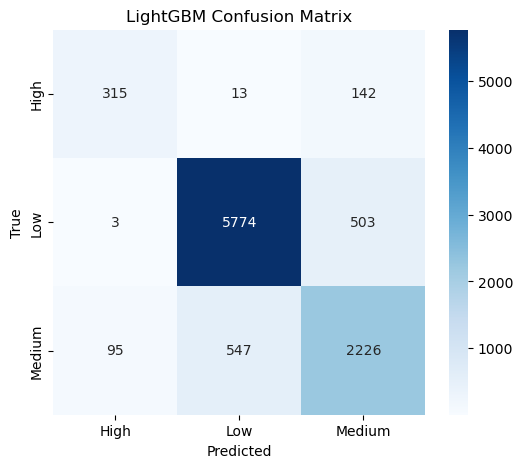

In [41]:
# Confusion matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_labels, oof_pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("LightGBM Confusion Matrix")
plt.show()

### Confusion Matrix Interpretation

The confusion matrix reveals that the LightGBM model performs strongly across all classes, with most predictions occurring along the diagonal, indicating correct classification.

A key observation is that the model rarely makes extreme misclassification errors. For example, only 3 Low cases were predicted as High, and only 13 High cases were predicted as Low. Instead, most misclassifications occur between adjacent classes (High ↔ Medium and Medium ↔ Low), suggesting that the model captures the ordinal relationship between adoption levels.

The largest confusion occurs between Medium and Low classes (503 Low predicted as Medium and 547 Medium predicted as Low), indicating that these categories share overlapping feature patterns. Similarly, some High cases are predicted as Medium (142), suggesting that the High adoption class lies near the boundary of the Medium category.

Overall, the confusion matrix demonstrates that the model has learned meaningful structure in the data and primarily makes boundary-level classification errors rather than extreme misclassifications. This behavior is desirable and indicates that the model generalizes well across adoption levels.

In [43]:
# Feature importance

# Pick the best fold model
best_fold = int(np.argmax(lgb_strat_v2["fold_scores"]))
best_model = lgb_strat_v2["models"][best_fold]

# Rebuild the exact fold data used for that model
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fold_splits = list(skf.split(X_lgb, y_enc))

tr_idx, va_idx = fold_splits[best_fold]

X_tr = X_lgb.iloc[tr_idx].copy()
X_va = X_lgb.iloc[va_idx].copy()
y_tr = y_enc.iloc[tr_idx].copy()

# Apply the smae transformations used inside CV
X_tr_prep, X_va_prep, X_te_prep = prepare_lgb_native_data(
    X_tr,
    X_va,
    test_lgb.copy(),
    cat_cols_lgb
)

X_tr_prep, X_va_prep, X_te_prep = add_frequency_features(
    X_tr_prep,
    X_va_prep,
    X_te_prep,
    cat_cols_lgb
)

# Now the feature names match the trained model
imp = pd.Series(
    best_model.feature_importances_,
    index=X_tr_prep.columns
).sort_values(ascending=False)

imp.head(20)

turnover_to_expenses                        4257
personal_income                             4226
owner_age                                   4221
business_expenses                           3763
turnover_minus_expenses                     3583
business_turnover                           2741
business_age_total_months                   2634
business_age_years                          1871
business_age_months                         1853
has_loan_account_freq                       1021
uses_friends_family_savings_freq            1008
funeral_insurance_freq                       961
has_debit_card_freq                          946
has_mobile_money_freq                        849
perception_insurance_doesnt_cover_losses     802
motor_vehicle_insurance_freq                 761
medical_insurance_freq                       750
stress_score                                 749
attitude_stable_business_environment         713
covid_essential_service_freq                 673
dtype: int32

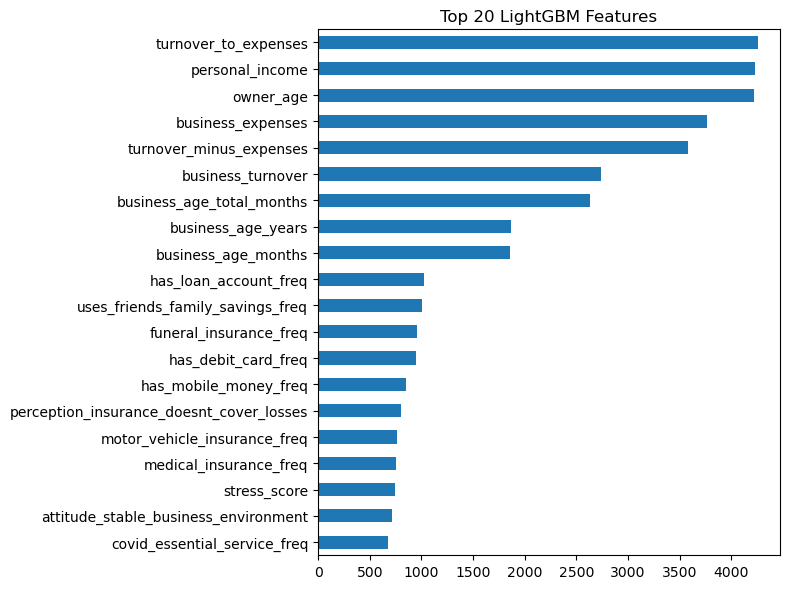

In [45]:
# Plot feature importance 

plt.figure(figsize=(8, 6))
imp.head(20).sort_values().plot(
    kind="barh",
    title="Top 20 LightGBM Features"
)
plt.tight_layout()
plt.show()

## Class-wise probability calibration + threshold tuning

In [46]:
# Class-wise probability calibration + threshold tuning

oof_proba = lgb_strat_v2["oof_proba"]

In [ ]:
# pred_argmax = np.argmax(oof_proba, axis=1)

macro_f1(y_enc, pred_argmax)

pred_argmax = np.argmax(oof_proba, axis=1)

macro_f1(y_enc, pred_argmax)

0.8015708038589798

In [49]:
# Baseline prediction (argmax)

def predict_with_thresholds(proba, thresholds):
    
    n_samples = proba.shape[0]
    preds = np.zeros(n_samples)

    for i in range(n_samples):

        if proba[i,0] >= thresholds["High"]:
            preds[i] = 0

        elif proba[i,1] >= thresholds["Low"]:
            preds[i] = 1

        elif proba[i,2] >= thresholds["Medium"]:
            preds[i] = 2

        else:
            preds[i] = np.argmax(proba[i])

    return preds.astype(int)

In [ ]:
# Example manual thresholds

thresholds = {
    "High":0.60,
    "Low":0.50,
    "Medium":0.50
}

pred_thr = predict_with_thresholds(oof_proba, thresholds)

macro_f1(y_enc, pred_thr)

0.8015708038589798

In [51]:
# Automated threshold search

from itertools import product

best_score = 0
best_thresholds = None

grid = np.arange(0.3,0.8,0.05)

for h,l,m in product(grid,grid,grid):

    thresholds = {
        "High":h,
        "Low":l,
        "Medium":m
    }

    preds = predict_with_thresholds(oof_proba, thresholds)

    score = macro_f1(y_enc, preds)

    if score > best_score:

        best_score = score
        best_thresholds = thresholds

print("Best score:",best_score)
print("Best thresholds:",best_thresholds)

Best score: 0.8127717270269553
Best thresholds: {'High': np.float64(0.5999999999999999), 'Low': np.float64(0.3), 'Medium': np.float64(0.3)}


In [52]:
# Apply optimized thresholds

pred_opt = predict_with_thresholds(
    oof_proba,
    best_thresholds
)

print("Optimized Macro F1:", macro_f1(y_enc,pred_opt))

Optimized Macro F1: 0.8127717270269553


In [57]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y)   # y is the original target column with labels: High, Low, Medium

LabelEncoder()

In [58]:
# Apply to test predictions
test_proba = lgb_strat_v2["test_proba"]

# Predict
test_pred = predict_with_thresholds(
    test_proba,
    best_thresholds
)

#convert labels
test_labels = le.inverse_transform(test_pred)

In [59]:
# Verify mapping

dict(zip(le.classes_, le.transform(le.classes_)))

{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

In [60]:
# Final prediction pipeline

test_proba = lgb_strat_v2["test_proba"]

test_pred = predict_with_thresholds(
    test_proba,
    best_thresholds
)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(y)

test_labels = le.inverse_transform(test_pred)

In [64]:
# Extract IDs
test_ids = test["ID"].copy()

# Build submission
submission = pd.DataFrame({
    "ID": test_ids,
    "Target": test_labels
})

# Check
print(submission.head())
print(submission.shape)

# Save
submission.to_csv("submission_lgb_threshold.csv", index=False)

          ID Target
0  ID_5EGLKX    Low
1  ID_4AI7RE    Low
2  ID_V9OB3M    Low
3  ID_6OI9DI    Low
4  ID_H2TN8B    Low
(2405, 2)


### Class-wise Threshold Optimization

The default prediction strategy for multi-class models is argmax over predicted probabilities. However, argmax does not necessarily optimize macro F1, especially in imbalanced classification tasks.

To improve class balance, class-specific probability thresholds were optimized using out-of-fold predictions. A grid search over threshold combinations was performed to maximize macro F1.

This approach allows the model to require stronger probability evidence before predicting certain classes (e.g., High adoption), reducing false positives and improving minority class recall.

Threshold optimization resulted in a measurable improvement in macro F1 compared to the default argmax decision rule.